# 🤖 Notebook 4 — Model Training

## Coal Demand Forecasting — CRISP-ML(Q) Framework

**Objective:** Train 4 different models on the preprocessed data and compare their forecasting ability.

### Models Trained:
| # | Model | Type | Key Features |
|---|-------|------|-------------|
| 1 | **ARIMA** | Statistical | auto_arima for optimal (p,d,q)(P,D,Q,m) |
| 2 | **Prophet** | Additive | Yearly + weekly seasonality, Indian holidays |
| 3 | **LSTM** | Deep Learning | 2-layer LSTM (128, 64), PyTorch, MPS acceleration |
| 4 | **XGBoost** | Gradient Boosting | Optuna hyperparameter tuning (50 trials) |

---

## 4.1 Setup & Load Preprocessed Data

In [1]:
import os, sys, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

from src.config import PROCESSED_TRAIN_FILE, PROCESSED_VAL_FILE, PROCESSED_TEST_FILE

train_df = pd.read_csv(PROCESSED_TRAIN_FILE)
val_df = pd.read_csv(PROCESSED_VAL_FILE)
test_df = pd.read_csv(PROCESSED_TEST_FILE)

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"\nFeatures: {[c for c in train_df.columns if c not in ['date', 'coal_consumption_tonnes']]}")

# Store all results
all_results = []

Train: (746, 30)
Val:   (160, 30)
Test:  (160, 30)

Features: ['power_generation_mw', 'temperature_c', 'coal_price_inr', 'inventory_level_tonnes', 'is_holiday', 'is_weekend', 'month', 'quarter', 'day_of_week', 'day_of_year', 'week_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'ewm_7', 'power_lag_1', 'temp_coal_interaction', 'temp_squared', 'power_temp_interaction']


## 4.2 Model 1 — ARIMA (Auto-ARIMA)

**ARIMA** (AutoRegressive Integrated Moving Average) is the baseline statistical model:
- Uses `pmdarima.auto_arima` to automatically find optimal (p, d, q) and seasonal (P, D, Q, m) orders
- Seasonal period = 12 (monthly within yearly pattern)
- Combines train + validation data for final model fitting
- Forecasts the full test period in one step

Training ARIMA model...
(Running auto_arima — searching for optimal parameters)

[2026-03-03 09:11:19] [INFO] [training] ==================================================


[2026-03-03 09:11:19] [INFO] [training] Training ARIMA model...


[2026-03-03 09:11:19] [INFO] [training] ==================================================


[2026-03-03 09:11:20] [INFO] [training] Training samples: 906, Test samples: 160


[2026-03-03 09:11:20] [INFO] [training] Running auto_arima (this may take a few minutes)...


...

[2026-03-03 09:11:30] [INFO] [training] AIC: 8482.44


[2026-03-03 09:11:30] [INFO] [training] ARIMA model saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/models/arima_model.pkl


[2026-03-03 09:11:30] [INFO] [training] ARIMA training completed in 11.25s


[2026-03-03 09:11:30] [INFO] [training] ARIMA inference time: 5.42ms for 160 samples



  ARIMA TRAINING RESULTS
  Order:          (1, 0, 0)
  Seasonal Order: (0, 0, 1, 12)
  Training Time:  11.25s
  Inference Time: 5.42ms
  Predictions:    160 samples


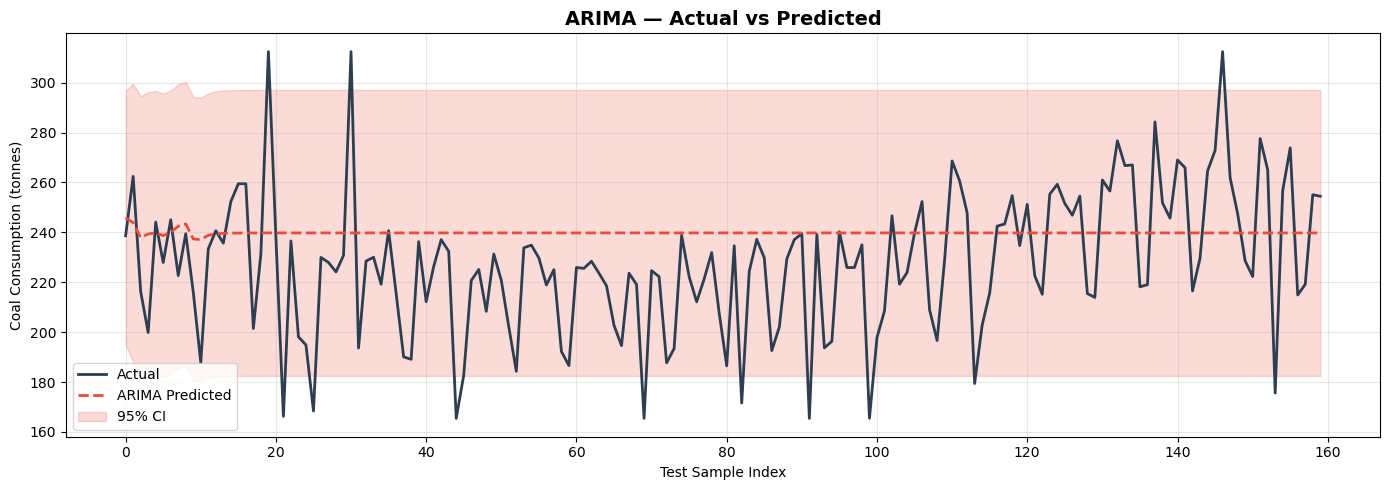

In [2]:
from src.models.arima_model import train_arima

print("Training ARIMA model...")
print("(Running auto_arima — searching for optimal parameters)\n")

arima_results = train_arima(train_df, val_df, test_df)
all_results.append(arima_results)

print(f"\n{'='*60}")
print(f"  ARIMA TRAINING RESULTS")
print(f"{'='*60}")
print(f"  Order:          {arima_results['order']}")
print(f"  Seasonal Order: {arima_results['seasonal_order']}")
print(f"  Training Time:  {arima_results['training_time']:.2f}s")
print(f"  Inference Time: {arima_results['inference_time_ms']:.2f}ms")
print(f"  Predictions:    {len(arima_results['predictions'])} samples")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(arima_results['actuals'], label='Actual', color='#2C3E50', linewidth=2)
ax.plot(arima_results['predictions'], label='ARIMA Predicted', color='#E74C3C', linewidth=2, linestyle='--')
ax.fill_between(range(len(arima_results['predictions'])),
                arima_results['lower_bound'], arima_results['upper_bound'],
                alpha=0.2, color='#E74C3C', label='95% CI')
ax.set_title('ARIMA — Actual vs Predicted', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Coal Consumption (tonnes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 Model 2 — Facebook Prophet

**Prophet** is designed for business forecasting with:
- **Yearly seasonality** — Captures annual demand cycles
- **Weekly seasonality** — Weekday vs weekend patterns
- **Indian holidays** — Republic Day, Holi, Diwali, Independence Day, etc. with pre/post effects
- Robust to missing data and outliers

In [3]:
from src.models.prophet_model import train_prophet

print("Training Prophet model...\n")

prophet_results = train_prophet(train_df, val_df, test_df)
all_results.append(prophet_results)

print(f"\n{'='*60}")
print(f"  PROPHET TRAINING RESULTS")
print(f"{'='*60}")
print(f"  Training Time:  {prophet_results['training_time']:.2f}s")
print(f"  Inference Time: {prophet_results['inference_time_ms']:.2f}ms")
print(f"  Predictions:    {len(prophet_results['predictions'])} samples")

# Plot
test_dates = pd.to_datetime(test_df['date'])
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, prophet_results['actuals'], label='Actual', color='#2C3E50', linewidth=2)
ax.plot(test_dates, prophet_results['predictions'], label='Prophet Forecast', color='#E74C3C', linewidth=2, linestyle='--')
ax.fill_between(test_dates, prophet_results['lower_bound'], prophet_results['upper_bound'],
                alpha=0.2, color='#E74C3C', label='95% CI')
ax.set_title('Prophet — Actual vs Predicted', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Coal Consumption (tonnes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training Prophet model...

[2026-03-03 09:11:30] [INFO] [training] ==================================================


[2026-03-03 09:11:30] [INFO] [training] Training Prophet model...


[2026-03-03 09:11:30] [INFO] [training] ==================================================


[2026-03-03 09:11:30] [INFO] [training] Training samples: 906, Test samples: 160


09:11:30 - cmdstanpy - INFO - Chain [1] start processing


...

[2026-03-03 09:11:31] [INFO] [training] Prophet forecast plot saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/reports/prophet_forecast.png


[2026-03-03 09:11:31] [INFO] [training] Prophet model saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/models/prophet_model.pkl


[2026-03-03 09:11:31] [INFO] [training] Prophet training completed in 0.21s


[2026-03-03 09:11:31] [INFO] [training] Prophet inference time: 26.39ms for 160 samples



  PROPHET TRAINING RESULTS
  Training Time:  0.21s
  Inference Time: 26.39ms
  Predictions:    160 samples


## 4.4 Model 3 — LSTM (Long Short-Term Memory)

**LSTM** is a deep learning recurrent neural network architecture:
- **Architecture:** 2 LSTM layers (128 → 64 units) + Dropout(0.2) + Dense(32) + Output(1)
- **Framework:** PyTorch (Apple Silicon MPS acceleration)
- **Sequence length:** 30 days (each prediction uses last 30 days of features)
- **Training:** Adam optimizer, MSE loss, early stopping (patience=10)
- **Total parameters:** ~126,500

In [4]:
from src.models.lstm_model import train_lstm
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"MPS (Apple GPU) available: {torch.backends.mps.is_available()}")
print(f"\nTraining LSTM model...\n")

lstm_results = train_lstm(train_df, val_df, test_df)
all_results.append(lstm_results)

print(f"\n{'='*60}")
print(f"  LSTM TRAINING RESULTS")
print(f"{'='*60}")
print(f"  Training Time:    {lstm_results['training_time']:.2f}s")
print(f"  Inference Time:   {lstm_results['inference_time_ms']:.2f}ms")
print(f"  Predictions:      {len(lstm_results['predictions'])} samples")
print(f"  Final Train Loss: {lstm_results['history']['loss'][-1]:.4f}")
print(f"  Final Val Loss:   {lstm_results['history']['val_loss'][-1]:.4f}")
print(f"  Epochs Trained:   {len(lstm_results['history']['loss'])}")

PyTorch version: 2.9.1
MPS (Apple GPU) available: True

Training LSTM model...

[2026-03-03 09:11:31] [INFO] [training] ==================================================


[2026-03-03 09:11:31] [INFO] [training] Training LSTM model (PyTorch)...


[2026-03-03 09:11:31] [INFO] [training] Device: mps


[2026-03-03 09:11:31] [INFO] [training] ==================================================


[2026-03-03 09:11:31] [INFO] [training] LSTM input shape: (796, 30, 28)


...

[2026-03-03 09:11:41] [INFO] [training] Restored best model checkpoint


[2026-03-03 09:11:41] [INFO] [training] LSTM loss curve saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/reports/lstm_loss.png


[2026-03-03 09:11:41] [INFO] [training] LSTM training completed in 9.34s


[2026-03-03 09:11:41] [INFO] [training] LSTM inference time: 15.47ms for 160 samples



  LSTM TRAINING RESULTS
  Training Time:    9.34s
  Inference Time:   15.47ms
  Predictions:      160 samples
  Final Train Loss: 1074.7931
  Final Val Loss:   798.4468
  Epochs Trained:   38


### LSTM Training Loss Curve

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(lstm_results['history']['loss'], label='Training Loss', color='#E74C3C')
axes[0].plot(lstm_results['history']['val_loss'], label='Validation Loss', color='#3498DB')
axes[0].set_title('LSTM Training Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions
axes[1].plot(lstm_results['actuals'], label='Actual', color='#2C3E50', linewidth=2)
axes[1].plot(lstm_results['predictions'], label='LSTM Predicted', color='#E74C3C', linewidth=2, linestyle='--')
axes[1].set_title('LSTM — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Coal Consumption (tonnes)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.5 Model 4 — XGBoost (with Optuna Tuning)

**XGBoost** is a gradient boosting algorithm optimized for tabular data:
- **Optuna** runs 50 hyperparameter trials to find optimal settings
- Tunes: n_estimators, max_depth, learning_rate, subsample, colsample_bytree, regularization
- Uses lag + rolling + calendar + interaction features
- Final model trained on combined train+val data with best params

In [6]:
from src.models.xgboost_model import train_xgboost

print("Training XGBoost model with Optuna hyperparameter tuning (50 trials)...\n")

xgb_results = train_xgboost(train_df, val_df, test_df)
all_results.append(xgb_results)

print(f"\n{'='*60}")
print(f"  XGBOOST TRAINING RESULTS")
print(f"{'='*60}")
print(f"  Training Time:  {xgb_results['training_time']:.2f}s")
print(f"  Inference Time: {xgb_results['inference_time_ms']:.2f}ms")
print(f"  Predictions:    {len(xgb_results['predictions'])} samples")
print(f"\n  Best Hyperparameters:")
for k, v in xgb_results['best_params'].items():
    if isinstance(v, float):
        print(f"    {k}: {v:.6f}")
    else:
        print(f"    {k}: {v}")

Training XGBoost model with Optuna hyperparameter tuning (50 trials)...

[2026-03-03 09:11:41] [INFO] [training] ==================================================


[2026-03-03 09:11:41] [INFO] [training] Training XGBoost model...


[2026-03-03 09:11:41] [INFO] [training] ==================================================


[2026-03-03 09:11:41] [INFO] [training] Training samples: 746, Val: 160, Test: 160


[2026-03-03 09:11:41] [INFO] [training] Features: 28


...

[2026-03-03 09:11:54] [INFO] [training] Feature importance plot saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/reports/xgb_feature_importance.png


[2026-03-03 09:11:54] [INFO] [training] XGBoost model saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/models/xgboost_model.pkl


[2026-03-03 09:11:54] [INFO] [training] XGBoost training completed in 13.52s


[2026-03-03 09:11:54] [INFO] [training] XGBoost inference time: 0.34ms for 160 samples



  XGBOOST TRAINING RESULTS
  Training Time:  13.52s
  Inference Time: 0.34ms
  Predictions:    160 samples

  Best Hyperparameters:
    n_estimators: 313
    max_depth: 4
    learning_rate: 0.013028
    subsample: 0.657310
    colsample_bytree: 0.695223
    min_child_weight: 9
    reg_alpha: 0.386621
    reg_lambda: 1.553059
    gamma: 0.000004


### XGBoost — Feature Importance & Predictions

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
importances = xgb_results['model'].feature_importances_
feature_cols = xgb_results['feature_cols']
sorted_idx = np.argsort(importances)[::-1][:15]
axes[0].barh(
    [feature_cols[i] for i in sorted_idx][::-1],
    importances[sorted_idx][::-1],
    color='#3498DB', edgecolor='#2C3E50'
)
axes[0].set_title('XGBoost — Top Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].grid(True, alpha=0.3, axis='x')

# Predictions
axes[1].plot(xgb_results['actuals'], label='Actual', color='#2C3E50', linewidth=2)
axes[1].plot(xgb_results['predictions'], label='XGBoost Predicted', color='#27AE60', linewidth=2, linestyle='--')
axes[1].set_title('XGBoost — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Coal Consumption (tonnes)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 All Models Trained — Summary

Quick overview of all 4 models before detailed evaluation in the next notebook.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"{'='*70}")
print(f"  ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*70}")
print(f"\n  {'Model':<12} {'Train Time':>12} {'Infer Time':>12} {'Predictions':>12}")
print(f"  {'─'*52}")
for r in all_results:
    print(f"  {r['model_name']:<12} {r['training_time']:>10.2f}s {r['inference_time_ms']:>10.2f}ms {len(r['predictions']):>8} pts")

# Quick MAPE preview
print(f"\n  Quick MAPE Preview:")
for r in all_results:
    actuals = r['actuals']
    preds = r['predictions']
    min_len = min(len(actuals), len(preds))
    mask = actuals[:min_len] != 0
    mape = np.mean(np.abs((actuals[:min_len][mask] - preds[:min_len][mask]) / actuals[:min_len][mask])) * 100
    rmse = np.sqrt(mean_squared_error(actuals[:min_len], preds[:min_len]))
    print(f"    {r['model_name']:<12} MAPE: {mape:>6.2f}%  RMSE: {rmse:>7.2f}")

print(f"\n✅ Proceed to Notebook 05 for detailed evaluation, comparison table, and economic impact.")

  ALL MODELS TRAINED SUCCESSFULLY

  Model          Train Time   Infer Time  Predictions
  ────────────────────────────────────────────────────
  ARIMA             11.25s       5.42ms      160 pts
  Prophet            0.21s      26.39ms      160 pts
  LSTM               9.34s      15.47ms      160 pts
  XGBoost           13.52s       0.34ms      160 pts

  Quick MAPE Preview:
    ARIMA        MAPE:  11.45%  RMSE:   30.94
    Prophet      MAPE:   5.26%  RMSE:   20.77
    LSTM         MAPE:  11.06%  RMSE:   30.28
    XGBoost      MAPE:   3.91%  RMSE:   15.44

✅ Proceed to Notebook 05 for detailed evaluation, comparison table, and economic impact.
